# Plot Zero-Variance extrapolation - 1D chain L = 20

In [92]:
import glob
import os
import sys

In [93]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
verbose = True

In [95]:
# Settings
L = 4 * 4                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [96]:
dossiers = glob.glob("../../datas/2D_4x4/datas_alpha_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.70178020
Extrapolated Energy       : -0.70151669 ± 0.00028976
95% Confidence Interval   : [-0.70210006 , -0.70095081]
Absolute Error vs Exact   : 2.64e-04


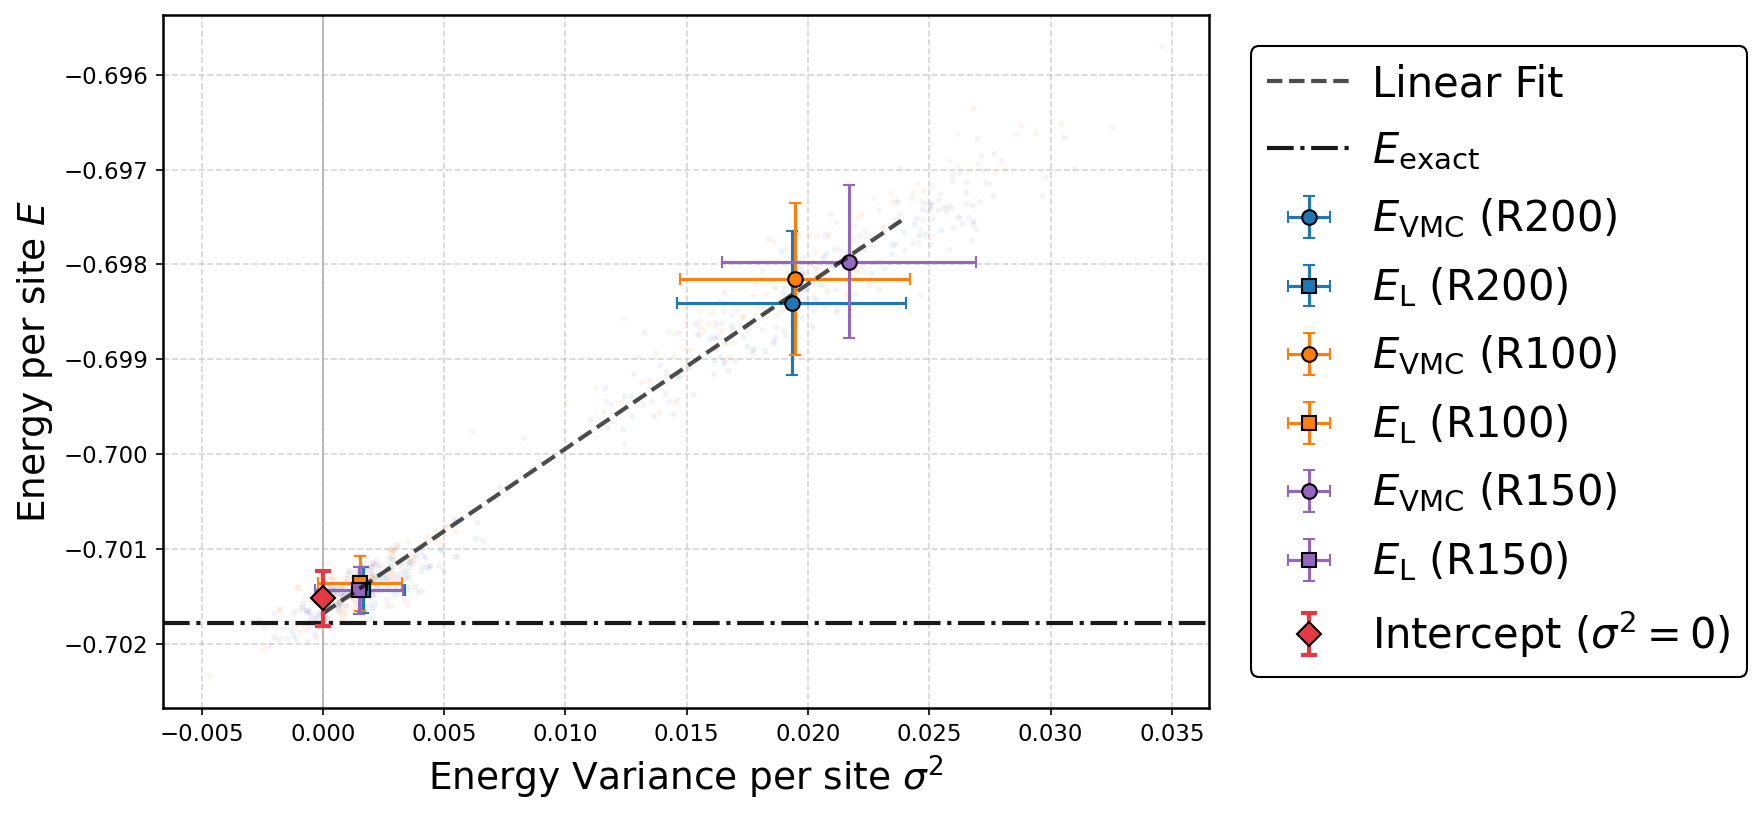

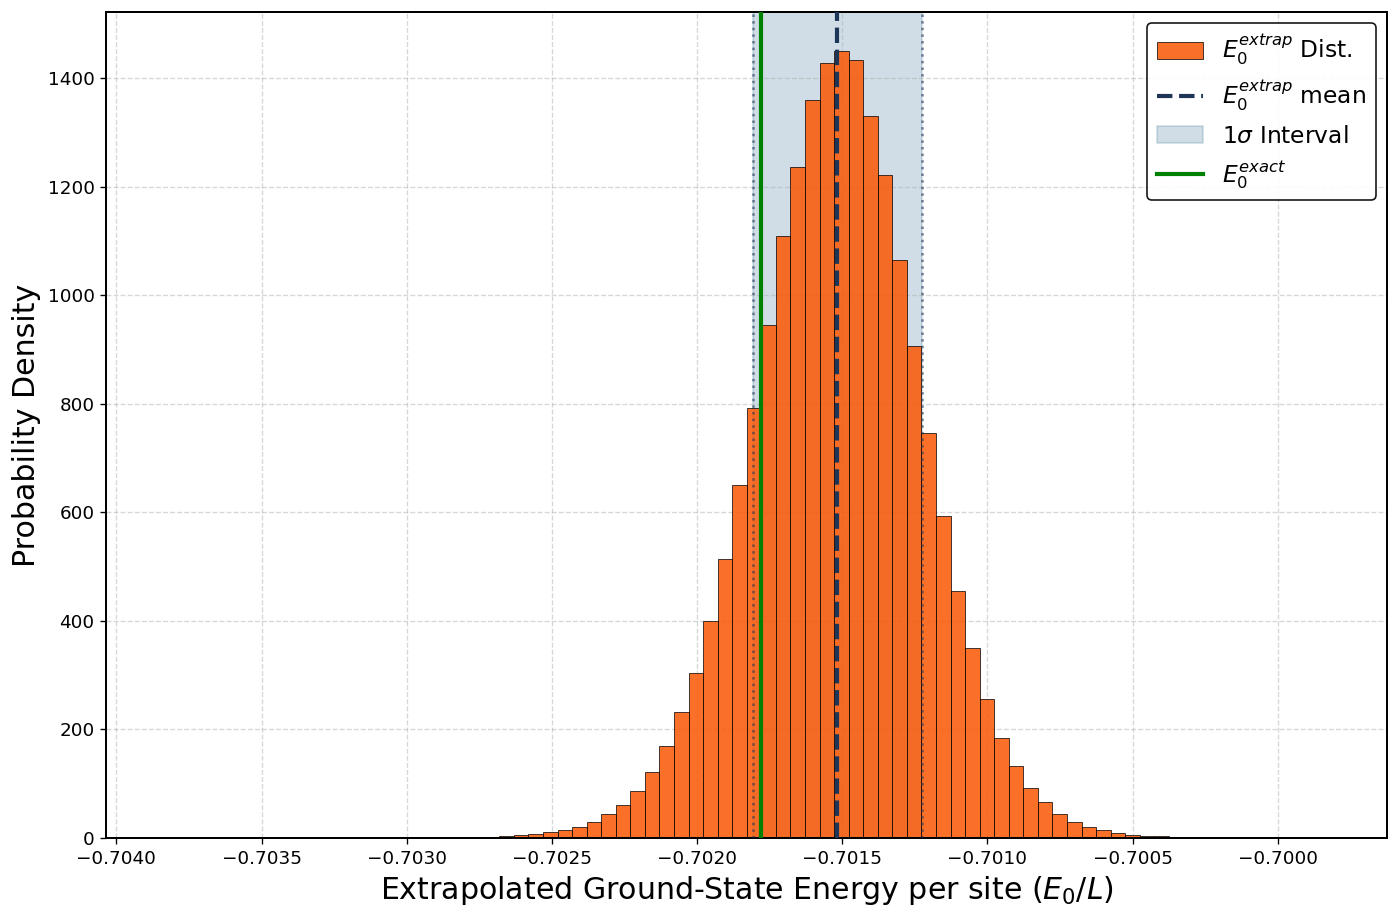

In [97]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(
    data_dict_AL, 
    mc_results_AL, 
    L, 
    save_dir="../../assets/2D_4x4", 
    name="AL_extrapolation_2d_hypercube"
)

plot_extrapolation_distribution(
    data_dict_AL, mc_results_AL, 
    save_dir="../../assets/2D_4x4", 
    name="AL_distribution_2d_hypercube"
)

In [98]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
    100   -0.698153 0.019463 0.013951       -0.701362     0.001540     0.003924
    150   -0.697971 0.021677 0.014723       -0.701435     0.001487     0.003857
    200   -0.698407 0.019321 0.013900       -0.701431     0.001667     0.004083


## Krylov Subspace 

In [99]:
dossiers = glob.glob("../../datas/2D_4x4/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.70178020
Extrapolated Energy       : -0.70189385 ± 0.00088233
95% Confidence Interval   : [-0.70387156 , -0.70042234]
Absolute Error vs Exact   : 1.14e-04


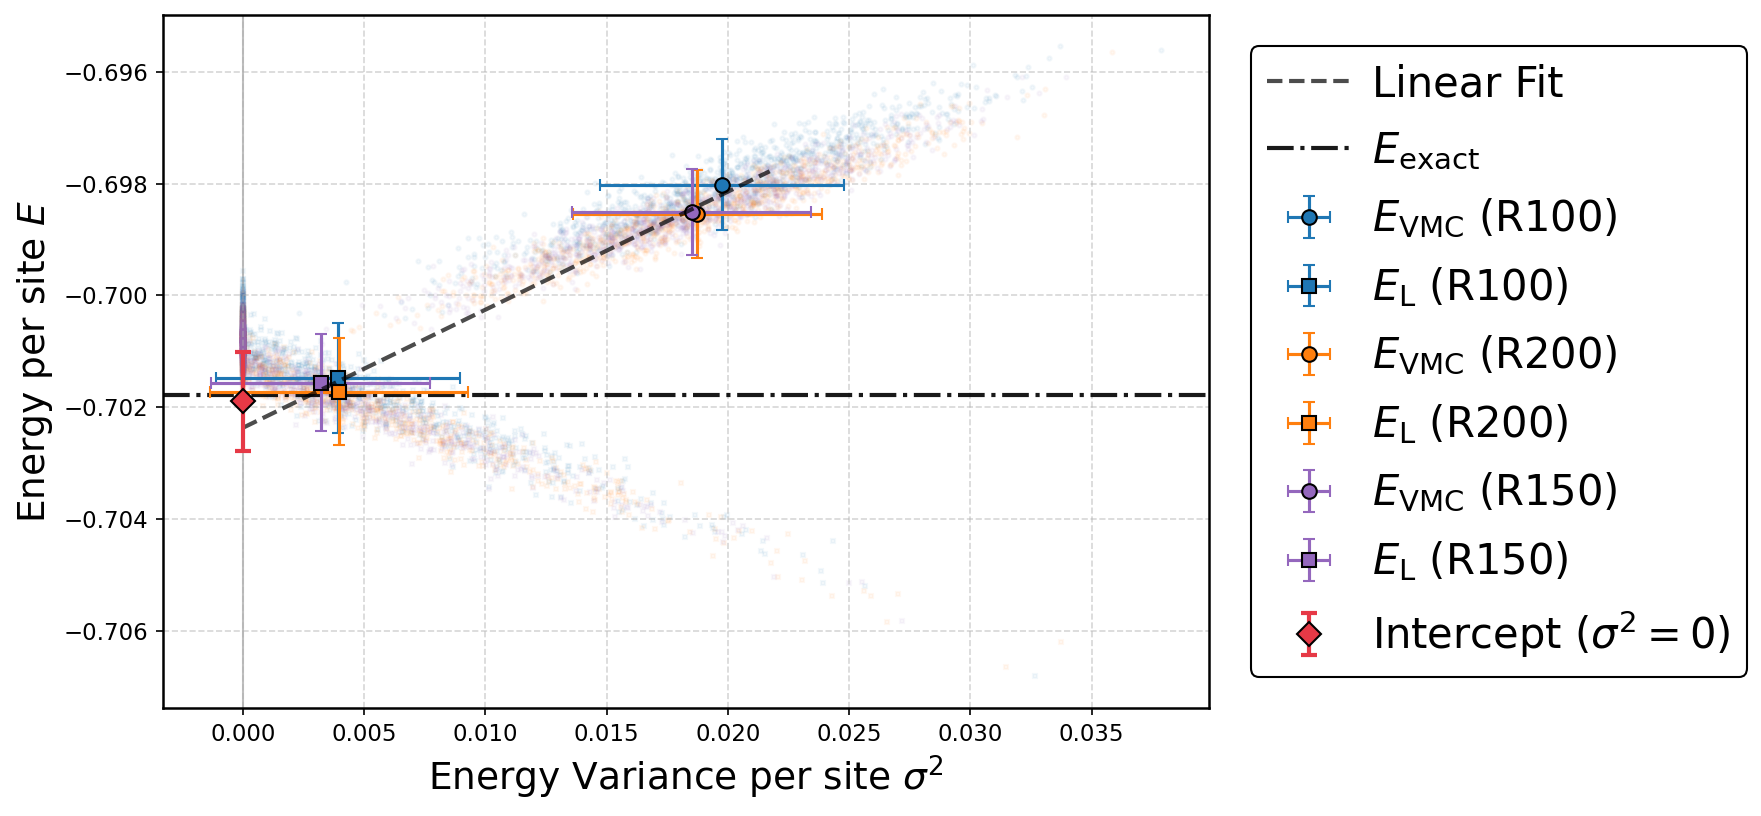

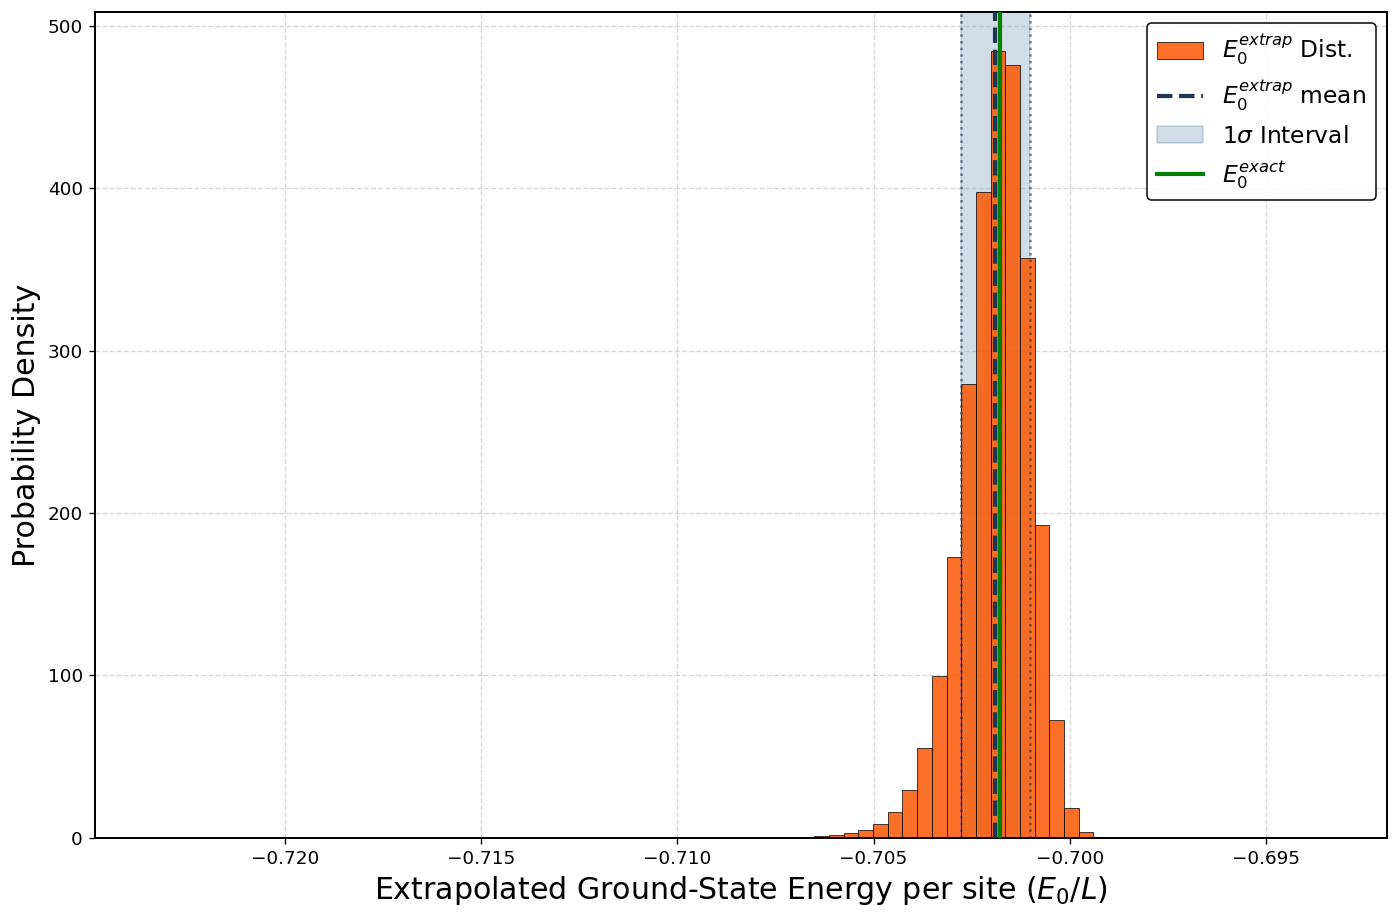

In [100]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets/2D_4x4", name="Krylov_extrapolation_2d_hypercube")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets/2D_4x4", name="Krylov_distribution_2d_hypercube")

In [101]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
    100   -0.698021 0.019752 0.004444       -0.701469     0.003927     0.001982
    150   -0.698509 0.018512 0.004303       -0.701563     0.003211     0.001792
    200   -0.698542 0.018746 0.004330       -0.701720     0.003974     0.001994


## Comparaison 

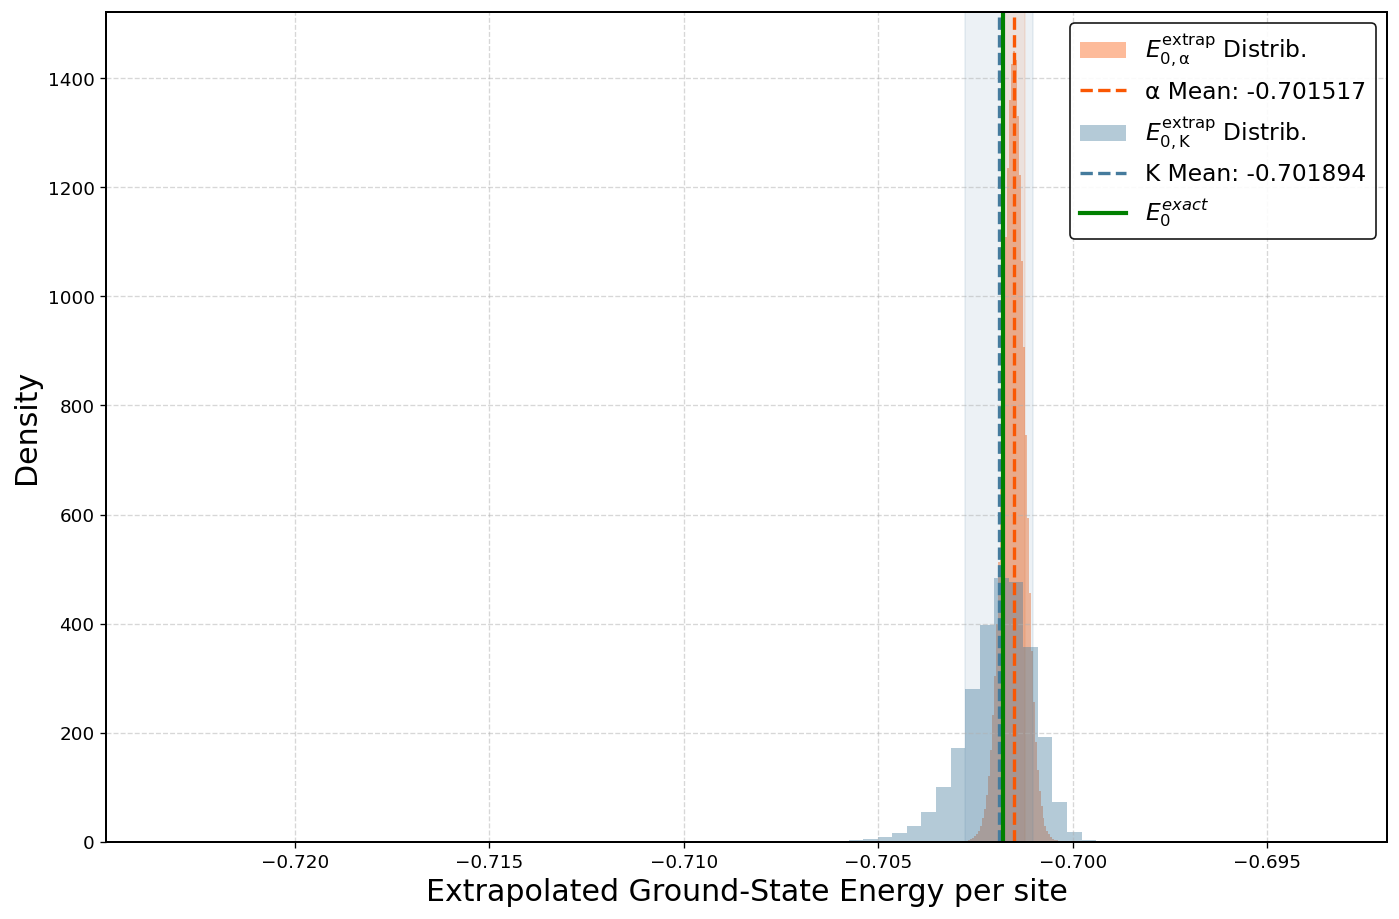

In [102]:
mes_distributions = {
    "α": mc_results_AL,
    "K": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(mes_distributions, E_exacte, save_dir="../../assets/2D_4x4")